In [1]:
import os
import wfdb
import numpy as np
import pandas as pd
from math import log
from json import loads
from scipy.stats import laplace
from scipy.linalg import inv, pinv, sqrtm, solve
from scipy.integrate import quad, IntegrationWarning

import matplotlib.pyplot as plt
from matplotlib.image import NonUniformImage

import logging
import warnings
logging.getLogger('matplotlib.pyplot').disabled = True
logging.getLogger('matplotlib.font_manager').disabled = True
logging.basicConfig(filename = 'info.log', filemode = 'w', level = logging.DEBUG)
warnings.simplefilter("ignore", category = IntegrationWarning)      # ignore integration precision warnings

/home/tshu/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Functional Approximation

In [2]:
INTLIM = 1000
INTLIM_PER_PIECE = 100

class PrivateLeastSquaresApprox:
    def __init__(self, interval, breakpoints, basis_type = 'Polynomial', degree = 1, weight = None):
        self.degree = degree
        self.l, self.r = interval
        self.breakpoints = breakpoints
        self.weight = weight if weight else lambda x: 1.0

        self.params = []
        for i in range(len(breakpoints)-1):
            if basis_type == 'Sinc':
                self.params.append({'l': breakpoints[i], 'r': breakpoints[i+1], 'k': -1})
            for k in range(degree+1):
                self.params.append({'l': breakpoints[i], 'r': breakpoints[i+1], 'k': k})
                if basis_type == 'Fourier' and k > 0:
                    self.params.append({'l': breakpoints[i], 'r': breakpoints[i+1], 'k': -k})

        # self.basis = lambda i, x: x**self.params[i]['k'] if x >= self.params[i]['l'] and x < self.params[i]['r'] else 0
        # self.basis = lambda i, x: np.where ((x >= self.params[i]['l']) & (x <= self.params[i]['r']), 
        #     ((x-(self.params[i]['l']+self.params[i]['r'])/2) / (self.params[i]['r']-self.params[i]['l']))**self.params[i]['k'], 0)
        if basis_type == 'Polynomial':
            self.basis = lambda i, x: np.where(
                (x >= self.params[i]['l']) & ((x < self.params[i]['r']) | ((self.params[i]['r'] == self.r) & (x == self.r))), 
                np.sqrt((2*self.params[i]['k']+1)/2) * 
                1/np.sqrt(((self.params[i]['r']-self.params[i]['l'])/2)**(2*self.params[i]['k']+1)) * 
                ((x-(self.params[i]['l']+self.params[i]['r'])/2)**self.params[i]['k']), 
                0)
        elif basis_type == 'Fourier':
            self.basis = lambda i, x: np.where(
                (x >= self.params[i]['l']) & ((x < self.params[i]['r']) | ((self.params[i]['r'] == self.r) & (x == self.r))), 
                (self.params[i]['k'] == 0) * 1 +
                (self.params[i]['k'] > 0) * np.sqrt(2)*np.sin(2*np.pi*self.params[i]['k']*(x-(self.params[i]['l']+self.params[i]['r'])/2)) + 
                (self.params[i]['k'] < 0) * np.sqrt(2)*np.cos(-2*np.pi*self.params[i]['k']*(x-(self.params[i]['l']+self.params[i]['r'])/2)), 
                0)
        elif basis_type == 'Sinc':
            self.basis = lambda i, x: np.where(
                (x >= self.params[i]['l']) & ((x < self.params[i]['r']) | ((self.params[i]['r'] == self.r) & (x == self.r))), 
                (self.params[i]['k'] == -1) * 1 + 
                (self.params[i]['k'] >= 0) * np.sinc(x-self.params[i]['l']-self.params[i]['k']), 
                0)
        else:
            logging.error(f"ERR: no such basis '{basis_type}'.")

        self.d = len(self.params)
        self.G = np.zeros((self.d, self.d))
        for i in range(self.d):
            for j in range(self.d):
                l_max = max(self.params[i]['l'], self.params[j]['l'])
                r_min = min(self.params[i]['r'], self.params[j]['r'])
                if l_max <= r_min:
                    integrand = lambda x: self.basis(i, x)*self.basis(j, x)*self.weight(x)
                    self.G[i,j], _ = quad(integrand, l_max, r_min, limit = INTLIM_PER_PIECE)
                else:
                    self.G[i,j] = 0
        self.invG = pinv(self.G)
        # np.set_printoptions(precision = 4, linewidth = 100, suppress = True)
        # logging.info("G = \n%s", self.G)
        # logging.info("inv(G) = \n%s", self.invG)
        if np.any(np.linalg.eigvals(self.G) < -1e-8):
            logging.error("ERR: the pairwise inner product matrix is not SPSD!")
        
    def solve(self, func, eps = 0.5, method = 'Laplace'):
        b = np.zeros(self.d)
        for i in range(self.d):
            integrand = lambda x: func(x)*self.basis(i, x)*self.weight(x)
            b[i], _ = quad(integrand, self.params[i]['l'], self.params[i]['r'], limit = INTLIM_PER_PIECE)
        # coeff = solve(self.G, b)
        coeff = self.invG@b
        # logging.info("b = %s", b)
        # logging.info("c = %s", coeff)
        
        def approx(x):
            ret = 0
            for i, c in enumerate(coeff):
                ret += c*self.basis(i, x)
            return ret

        if method == None:
            noise = np.zeros(self.d)
        elif method == 'Laplace':
            noise = np.random.normal(0, 1, (self.d,))
            noise = np.sqrt(np.random.exponential(1))*noise
            noise = (sqrtm(self.invG)@noise).real
            noise = noise/eps
        elif method == 'Normal':
            noise = np.random.normal(0, 1, (self.d,))
            noise = (sqrtm(self.invG)@noise).real/np.sqrt(2*eps)
        else:
            logging.error(f"ERR: no such method '{method}'.")
        # logging.info("noise = %s", noise)

        def priv_approx(x):
            ret = 0
            for i in range(self.d):
                ret += (coeff[i]+noise[i])*self.basis(i, x)
            return ret

        return coeff, noise, approx, priv_approx
    
    def eval(self, func, approx, priv_approx):
        integrand = lambda x: (func(x)-approx(x))**2
        err_ls, _ = quad(integrand, self.l, self.r, limit = INTLIM)
        err_ls = np.sqrt(err_ls)
        integrand = lambda x: (func(x)-priv_approx(x))**2
        err_priv, _ = quad(integrand, self.l, self.r, limit = INTLIM)
        err_priv = np.sqrt(err_priv)
        return err_ls, err_priv

def l2_dist(f, g, l, r):
    integrand = lambda x: (f(x)-g(x))**2
    dist, _ = quad(integrand, l, r, limit = INTLIM)
    dist = np.sqrt(dist)
    return dist

In [3]:
def reduce_seg(func, interval, basis, degree, k0, k, total_eps, eps, beta):
    if k == 0:
        return np.array(interval), total_eps
    breakpoints = np.linspace(interval[0], interval[1], (2**k)+1)
    solver = PrivateLeastSquaresApprox(interval, breakpoints, basis, degree)
    _, _, approx, _ = solver.solve(func, 0, method = None)
    err = l2_dist(func, approx, interval[0], interval[1])
    noise = laplace.rvs(scale = 1/eps)
    total_eps = total_eps-eps
    logging.info(f"ReduceSeg at interval {interval} with breakpoints {breakpoints}:\n"+
                 f"\tB = {total_eps:.5f}, eps = {eps:.5f}, err = {err:.5f}, noise = {noise:.5f},"+
                 f"offset = {(log(2)*k0-log(1/beta))/eps:.5f};"+
                 f"Proceed? {err+noise+(np.log(2)*k0-np.log(1/beta))/eps <= 2**(k-1)}.")
    
    if err+noise+(np.log(2)*k0-np.log(1/beta))/eps <= 2**(k-1):
        if k == 1:
            breakpoints = np.array(interval)
        else:
            l_pts, total_eps = reduce_seg(func, (interval[0], (interval[0]+interval[1])/2), basis, degree, k0, k-2, total_eps, eps/4, beta)
            r_pts, total_eps = reduce_seg(func, ((interval[0]+interval[1])/2, interval[1]), basis, degree, k0, k-2, total_eps, eps/4, beta)
            breakpoints = np.concatenate((l_pts[:-1], r_pts))
    return breakpoints, total_eps

def adaptive_poly_approx(func, interval, basis = 'Polynomial', degree = 1, eps = 0.5, beta = 0.5, method = 'Laplace'):
    logging.info("="*100)
    logging.info(f"Adaptive Private Function Approximation with degree-{degree} polynomials (eps = {eps}, beta = {beta})")
    # SVT using eps/4 privacy quota (eps_1 = eps/12, eps_2 = eps/6)
    k_bar = 0
    w = laplace.rvs(scale = 12/eps)
    while True:
        breakpoints = np.linspace(interval[0], interval[1], (2**k_bar)+1)
        solver = PrivateLeastSquaresApprox(interval, breakpoints, basis, degree)
        _, _, approx, _ = solver.solve(func, 0, method = None)
        v = laplace.rvs(scale = 12/eps)
        tau = (2**k_bar)*4/eps
        err = l2_dist(func, approx, interval[0], interval[1])
        logging.info(f"SVT: k_bar = {k_bar}, tau = {tau}, err = {err:.5f}, w = {w:.5f}, v = {v:.5f}; Terminate? {tau-err+v >= w}.")
        if tau-err+v >= w:
            break
        k_bar = k_bar+1
    logging.info(f"Final k_bar = {k_bar}.")
    logging.info("-"*100)

    B = 3*eps/4
    k0 = min(k_bar-2, 4)
    if k0 < 1:
        breakpoints = np.linspace(interval[0], interval[1], (2**k_bar)+1)
    else:
        # recursively merge pieces in subintervals
        # 3/4*eps privacy quota left, each quad-interval consumes 1/16*eps quota
        # then there will be at least 1/2*eps quota left for final privatization
        breakpoints = np.array([interval[0]])
        for i in range(4):
            pts, B = reduce_seg(func, (interval[0]+(interval[1]-interval[0])*i/4, interval[0]+(interval[1]-interval[0])*(i+1)/4), 
                                basis, degree, k0, k_bar-2, B, eps/32, beta)
            breakpoints = np.concatenate((breakpoints[:-1], pts))
    logging.info(f"Final breakpoints: {breakpoints}, remaining eps = {B:.5f}.")
    logging.info("-"*100)

    solver = PrivateLeastSquaresApprox(interval, breakpoints, basis, degree)
    _, _, approx, priv = solver.solve(func, B, method = method)
    err_ls = l2_dist(func, approx, interval[0], interval[1])
    err_priv = l2_dist(func, priv, interval[0], interval[1])
    logging.info(f"Polynomial approximation (eps = {B:.5f}, degree {solver.degree}):")
    logging.info(f"\tbreakpoints: {solver.breakpoints};")
    logging.info(f"\t||f-f_approx|| = {err_ls:.5f}, ||f-f_priv|| = {err_priv:.5f}.\n")
    return approx, priv, err_ls, err_priv

In [4]:
def time_series_func(t, val):
    def func(x):
        return np.interp(x, t, val)
        """
        if isinstance(x, (int, float)):
            idx = np.searchsorted(t, x, side = 'right')
            if idx > 0 and idx < len(t):
                return (t[idx]-x)/(t[idx]-t[idx-1])*val[idx-1]+(x-t[idx-1])/(t[idx]-t[idx-1])*val[idx]
            if idx == len(t):
                return val[-1]
            return val[0]
        else:
            return np.array([func(y) for y in x])
        """
    return func

def plot_1D_1D(func, interval, approx, priv, err_ls, err_priv, eps, degree, method):
    x_plot = np.linspace(interval[0], interval[1], INTLIM)
    y_true = func(x_plot)
    y_approx = approx(x_plot)
    y_priv = priv(x_plot)

    plt.figure(figsize = (6, 4))
    plt.plot(x_plot, y_true, 'k-', linewidth = 2, label = 'True Function')
    plt.plot(x_plot, y_approx, 'r--', linewidth = 1.5, label = 'Poly Approx')
    plt.plot(x_plot, y_priv, 'b--', linewidth = 1.5, label = f'Private Poly Approx ({method})')
    plt.title(f"eps = {eps}, degree = {degree}, error: {err_priv:.5f} ({err_ls:.5f})")
    plt.legend(loc = 'upper left')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

## Approximations with Polynomial Basis

### Gaussian Examples

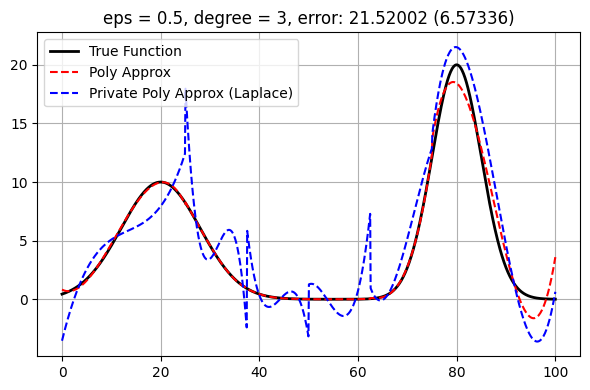

In [5]:
func = lambda x: 10*np.exp(-(x-20)**2/(2*8*8))+20*np.exp(-(x-80)**2/(2*5*5))
approx, priv, err_ls, err_priv = adaptive_poly_approx(func = func, interval = (0, 100), basis = 'Polynomial', degree = 3)
plot_1D_1D(func, (0, 100), approx, priv, err_ls, err_priv, 0.5, 3, 'Laplace')

In [6]:
solver = PrivateLeastSquaresApprox((0, 100), np.linspace(0, 100, 4), degree = 3)

func = lambda x: np.exp(-(x-20)**2/(2*8*8))+2*np.exp(-(x-80)**2/(2*5*5))
err_ls_sum = 0; err_priv_sum = 0; err_total_sum = 0
for i in range(20):
    _, _, approx, priv = solver.solve(func, method = 'Laplace')
    err_ls_sum += l2_dist(func, approx, 0, 100)
    err_priv_sum += l2_dist(approx, priv, 0, 100)
    err_total_sum += l2_dist(func, priv, 0, 100)
print(f"||f-f_approx|| = {err_ls_sum/20:.5f};", end = ' ')
print(f"||f_approx-f_priv|| = {err_priv_sum/20:.5f};", end = ' ')
print(f"||f-f_priv|| = {err_total_sum/20:.5f}.")

func = lambda x: 10*np.exp(-(x-20)**2/(2*8*8))+20*np.exp(-(x-80)**2/(2*5*5))
err_ls_sum = 0; err_priv_sum = 0; err_total_sum = 0
for i in range(20):
    _, _, approx, priv = solver.solve(func, method = 'Laplace')
    err_ls_sum += l2_dist(func, approx, 0, 100)
    err_priv_sum += l2_dist(approx, priv, 0, 100)
    err_total_sum += l2_dist(func, priv, 0, 100)
print(f"||f-f_approx|| = {err_ls_sum/20:.5f};", end = ' ')
print(f"||f_approx-f_priv|| = {err_priv_sum/20:.5f};", end = ' ')
print(f"||f-f_priv|| = {err_total_sum/20:.5f}.")

func = lambda x: 100*np.exp(-(x-20)**2/(2*8*8))+200*np.exp(-(x-80)**2/(2*5*5))
err_ls_sum = 0; err_priv_sum = 0; err_total_sum = 0
for i in range(20):
    _, _, approx, priv = solver.solve(func, method = 'Laplace')
    err_ls_sum += l2_dist(func, approx, 0, 100)
    err_priv_sum += l2_dist(approx, priv, 0, 100)
    err_total_sum += l2_dist(func, priv, 0, 100)
print(f"||f-f_approx|| = {err_ls_sum/20:.5f};", end = ' ')
print(f"||f_approx-f_priv|| = {err_priv_sum/20:.5f};", end = ' ')
print(f"||f-f_priv|| = {err_total_sum/20:.5f}.")

||f-f_approx|| = 1.61463; ||f_approx-f_priv|| = 6.11030; ||f-f_priv|| = 6.40878.
||f-f_approx|| = 16.14626; ||f_approx-f_priv|| = 5.55129; ||f-f_priv|| = 17.39038.
||f-f_approx|| = 161.46256; ||f_approx-f_priv|| = 6.73950; ||f-f_priv|| = 161.65072.


In [7]:
func = lambda x: 10*np.exp(-(x-0.2)**2/(2*0.08*0.08))+20*np.exp(-(x-0.8)**2/(2*0.05*0.05))
solver = PrivateLeastSquaresApprox((0, 1), np.linspace(0, 1, 4), degree = 3)
err_ls_sum = 0; err_priv_sum = 0; err_total_sum = 0
for i in range(20):
    _, _, approx, priv = solver.solve(func, method = 'Laplace')
    err_ls_sum += l2_dist(func, approx, 0, 1)
    err_priv_sum += l2_dist(approx, priv, 0, 1)
    err_total_sum += l2_dist(func, priv, 0, 1)
print(f"||f-f_approx|| = {err_ls_sum/20:.5f};", end = ' ')
print(f"||f_approx-f_priv|| = {err_priv_sum/20:.5f};", end = ' ')
print(f"||f-f_priv|| = {err_total_sum/20:.5f}.")

func = lambda x: 10*np.exp(-(x-2)**2/(2*0.8*0.8))+20*np.exp(-(x-8)**2/(2*0.5*0.5))
solver = PrivateLeastSquaresApprox((0, 10), np.linspace(0, 10, 4), degree = 3)
err_ls_sum = 0; err_priv_sum = 0; err_total_sum = 0
for i in range(20):
    _, _, approx, priv = solver.solve(func, method = 'Laplace')
    err_ls_sum += l2_dist(func, approx, 0, 10)
    err_priv_sum += l2_dist(approx, priv, 0, 10)
    err_total_sum += l2_dist(func, priv, 0, 10)
print(f"||f-f_approx|| = {err_ls_sum/20:.5f};", end = ' ')
print(f"||f_approx-f_priv|| = {err_priv_sum/20:.5f};", end = ' ')
print(f"||f-f_priv|| = {err_total_sum/20:.5f}.")

func = lambda x: 10*np.exp(-(x-20)**2/(2*8*8))+20*np.exp(-(x-80)**2/(2*5*5))
solver = PrivateLeastSquaresApprox((0, 100), np.linspace(0, 100, 4), degree = 3)
err_ls_sum = 0; err_priv_sum = 0; err_total_sum = 0
for i in range(20):
    _, _, approx, priv = solver.solve(func, method = 'Laplace')
    err_ls_sum += l2_dist(func, approx, 0, 100)
    err_priv_sum += l2_dist(approx, priv, 0, 100)
    err_total_sum += l2_dist(func, priv, 0, 100)
print(f"||f-f_approx|| = {err_ls_sum/20:.5f};", end = ' ')
print(f"||f_approx-f_priv|| = {err_priv_sum/20:.5f};", end = ' ')
print(f"||f-f_priv|| = {err_total_sum/20:.5f}.")

||f-f_approx|| = 1.61463; ||f_approx-f_priv|| = 6.06647; ||f-f_priv|| = 6.37018.
||f-f_approx|| = 5.10589; ||f_approx-f_priv|| = 4.66389; ||f-f_priv|| = 7.25404.
||f-f_approx|| = 16.14626; ||f_approx-f_priv|| = 6.24886; ||f-f_priv|| = 17.50574.


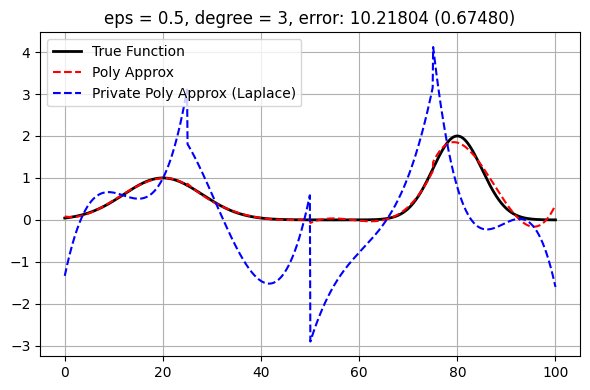

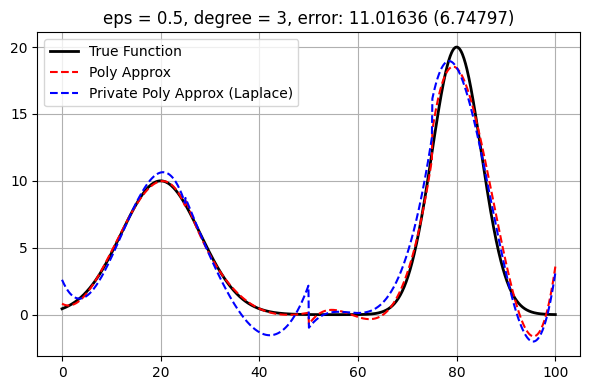

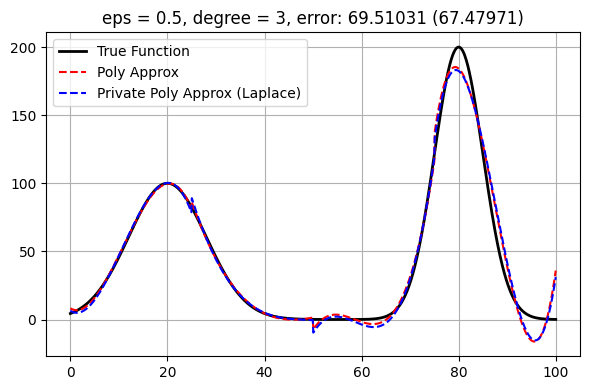

In [8]:
solver = PrivateLeastSquaresApprox((0, 100), [0, 25, 50, 75, 100], degree = 3)

func = lambda x: np.exp(-(x-20)**2/(2*8*8))+2*np.exp(-(x-80)**2/(2*5*5))
_, _, approx, priv = solver.solve(func, 0.5, method = 'Laplace')
err_ls = l2_dist(func, approx, 0, 100)
err_priv = l2_dist(func, priv, 0, 100)
plot_1D_1D(func, (0, 100), approx, priv, err_ls, err_priv, 0.5, 3, 'Laplace')

func = lambda x: 10*np.exp(-(x-20)**2/(2*8*8))+20*np.exp(-(x-80)**2/(2*5*5))
_, _, approx, priv = solver.solve(func, 0.5, method = 'Laplace')
err_ls = l2_dist(func, approx, 0, 100)
err_priv = l2_dist(func, priv, 0, 100)
plot_1D_1D(func, (0, 100), approx, priv, err_ls, err_priv, 0.5, 3, 'Laplace')

func = lambda x: 100*np.exp(-(x-20)**2/(2*8*8))+200*np.exp(-(x-80)**2/(2*5*5))
_, _, approx, priv = solver.solve(func, 0.5, method = 'Laplace')
err_ls = l2_dist(func, approx, 0, 100)
err_priv = l2_dist(func, priv, 0, 100)
plot_1D_1D(func, (0, 100), approx, priv, err_ls, err_priv, 0.5, 3, 'Laplace')

### Taxi Trajectory

In [9]:
filename_list = []; x_list = []; y_list = []; t_list = []
for filename in os.listdir("cabspottingdata"):
    if filename != "_cabs.txt" and filename != "README":
        track = pd.read_csv("cabspottingdata/"+filename, header = None, sep = '\s+')
        filename_list.append(filename)
        x_list.append(track[0].to_numpy()[::-1])
        y_list.append(track[1].to_numpy()[::-1])
        t_list.append(track[3].to_numpy()[::-1]-track[3].to_numpy()[-1])
df = pd.DataFrame({'filename': filename_list, 't': t_list, 'x': x_list, 'y': y_list})
df['x_min'] = df['x'].apply(np.min)
df['x_max'] = df['x'].apply(np.max)
df['y_min'] = df['y'].apply(np.min)
df['y_max'] = df['y'].apply(np.max)
df

,filename,t,x,y,x_min,x_max,y_min,y_max
0,new_auctjir.txt,"[0, 61, 121, 191, 252, 267, 273, 339, 392, 423...","[37.78615, 37.7862, 37.78629, 37.78618, 37.786...","[-122.40628, -122.40181, -122.39917, -122.4014...",37.37463,37.98136,-122.53711,-122.00207
1,new_ucdewy.txt,"[0, 60, 120, 180, 241, 301, 361, 423, 483, 546...","[37.7516, 37.75158, 37.75158, 37.75151, 37.751...","[-122.3941, -122.39415, -122.39415, -122.39366...",37.61445,37.87914,-122.50999,-122.22118
2,new_iapberci.txt,"[0, 66, 127, 180, 210, 254, 315, 375, 435, 501...","[37.76457, 37.76487, 37.7608, 37.75877, 37.758...","[-122.4077, -122.40239, -122.40122, -122.40105...",37.46440,37.90360,-122.51671,-122.00511
3,new_ajixdo.txt,"[0, 60, 131, 135, 196, 260, 317, 377, 438, 498...","[37.73507, 37.73859, 37.73913, 37.73923, 37.73...","[-122.39054, -122.38932, -122.39144, -122.3916...",37.42051,50.30546,-122.51685,-122.00000
4,new_ockihoba.txt,"[0, 15, 66, 138, 208, 264, 314, 374, 435, 500,...","[37.71494, 37.71494, 37.72762, 37.7318, 37.739...","[-122.4502, -122.4502, -122.44443, -122.41994,...",37.54571,37.99991,-122.57818,-122.00227
...,...,...,...,...,...,...,...,...
531,new_oipial.txt,"[0, 61, 125, 180, 240, 303, 350, 410, 475, 543...","[37.75166, 37.75166, 37.75166, 37.7516, 37.751...","[-122.39524, -122.39525, -122.39526, -122.3952...",37.55513,37.96520,-122.53674,-122.06104
532,new_otswrank.txt,"[0, 10, 76, 130, 190, 250, 310, 370, 425, 471,...","[37.58844, 37.75143, 37.75137, 37.75137, 37.75...","[-122.16055, -122.39363, -122.39361, -122.3936...",37.37591,37.93019,-122.51380,-122.06111
533,new_egreosko.txt,"[0, 61, 115, 175, 200, 260, 320, 380, 440, 500...","[37.7398, 37.74429, 37.74709, 37.75609, 37.757...","[-122.46467, -122.45373, -122.44438, -122.4409...",37.12274,37.95592,-122.54272,-122.00486
534,new_eapceou.txt,"[0, 60, 120, 183, 215, 224, 284, 344, 404, 464...","[37.78607, 37.788, 37.79307, 37.798, 37.79923,...","[-122.44002, -122.44038, -122.44142, -122.4424...",37.23584,37.93646,-122.53604,-122.00730


In [10]:
np.sum([df['t'][i].shape[0] for i in range(df.shape[0])])

np.int64(11219955)

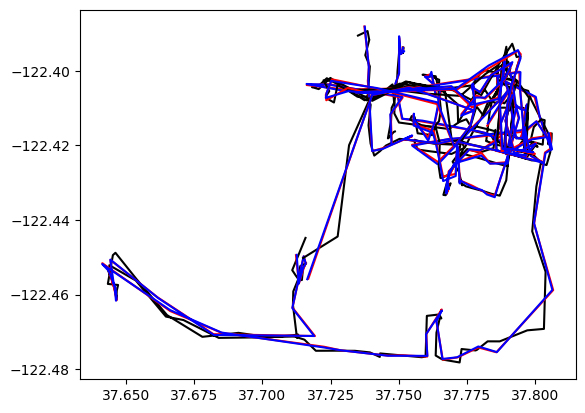

CPU times: user 2min 8s, sys: 168 ms, total: 2min 8s
Wall time: 1min 28s


In [11]:
%%time
# for i in range(df.shape[0]):
for i in range(5):
    t = df['t'][i][:100]
    x = (df['x'][i][:100]-df['x_min'][i])*1000
    y = (df['y'][i][:100]-df['y_min'][i])*1000
    func_x = time_series_func(t, x)
    func_y = time_series_func(t, y)
    approx_x, priv_x, err_ls_x, err_priv_x = adaptive_poly_approx(func = func_x, interval = (0, t[-1]), degree = 1)
    approx_y, priv_y, err_ls_y, err_priv_y = adaptive_poly_approx(func = func_y, interval = (0, t[-1]), degree = 1)
    logging.info(f"Approx x: {approx_x(t)}\nApprox y: {approx_y(t)}\n\n")
    plt.plot(x/1000+df['x_min'][i], y/1000+df['y_min'][i], color = 'black')
    plt.plot(approx_x(t)/1000+df['x_min'][i], approx_y(t)/1000+df['y_min'][i], color = 'red')
    plt.plot(priv_x(t)/1000+df['x_min'][i], priv_y(t)/1000+df['y_min'][i], color = 'blue')
plt.show()

158.7241828784039 160.0144920160828
119.491356785275 119.79957883347089


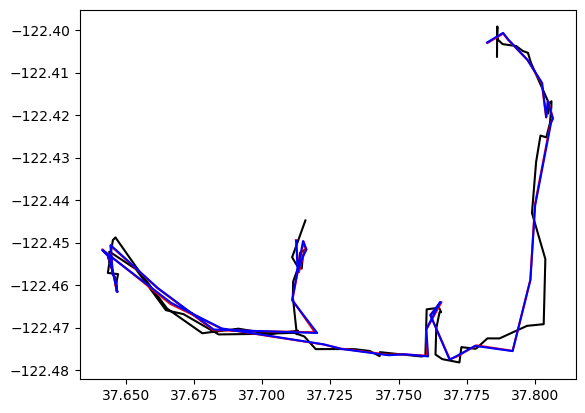

CPU times: user 48.6 s, sys: 117 ms, total: 48.7 s
Wall time: 32.1 s


In [12]:
%%time
for i in range(1):
    t = df['t'][i][:100]
    x = (df['x'][i][:100]-df['x_min'][i])*1000
    y = (df['y'][i][:100]-df['y_min'][i])*1000
    func_x = time_series_func(t, x)
    func_y = time_series_func(t, y)
    approx_x, priv_x, err_ls_x, err_priv_x = adaptive_poly_approx(func = func_x, interval = (0, t[-1]), degree = 1)
    approx_y, priv_y, err_ls_y, err_priv_y = adaptive_poly_approx(func = func_y, interval = (0, t[-1]), degree = 1)
    # logging.info(f"Approx x: {approx_x(t)}\nApprox y: {approx_y(t)}\n\n")
    print(l2_dist(func_x, approx_x, t[0], t[-1]), l2_dist(func_x, priv_x, t[0], t[-1]))
    print(l2_dist(func_y, approx_y, t[0], t[-1]), l2_dist(func_y, priv_y, t[0], t[-1]))
    plt.plot(x/1000+df['x_min'][i], y/1000+df['y_min'][i], color = 'black')
    plt.plot(approx_x(t)/1000+df['x_min'][i], approx_y(t)/1000+df['y_min'][i], color = 'red')
    plt.plot(priv_x(t)/1000+df['x_min'][i], priv_y(t)/1000+df['y_min'][i], color = 'blue')
plt.show()

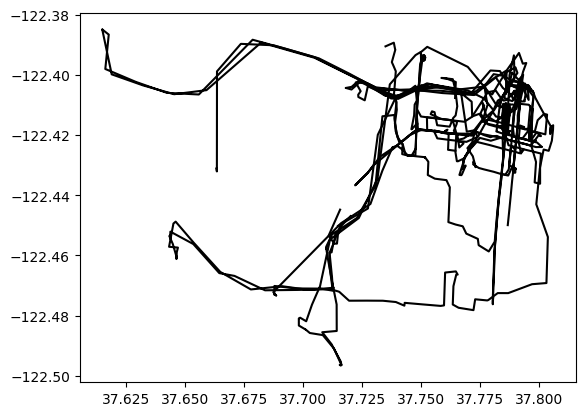

In [13]:
# for i in range(df.shape[0]):
for i in range(10):
    x = (df['x'][i][:100]-df['x_min'][i])
    y = (df['y'][i][:100]-df['y_min'][i])
    plt.plot(x+df['x_min'][i], y+df['y_min'][i], color = 'black')
plt.show()

## Approximations with Fourier Basis

### Trigonometric Examples

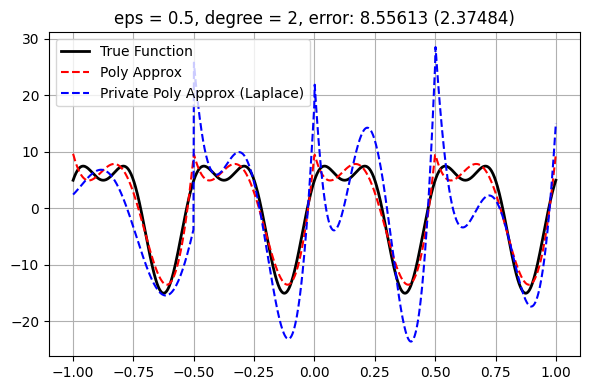

In [14]:
func = lambda x: 10*np.sin(4*np.pi*x)+5*np.cos(8*np.pi*x)
approx, priv, err_ls, err_priv = adaptive_poly_approx(func = func, interval = (-1, 1), basis = 'Fourier', degree = 2)
plot_1D_1D(func, (-1, 1), approx, priv, err_ls, err_priv, 0.5, 2, 'Laplace')

In [15]:
solver = PrivateLeastSquaresApprox((-1, 1), [-1, 1], 'Fourier', degree = 2)

func = lambda x: 1*np.sin(4*np.pi*x)+0.5*np.cos(8*np.pi*x)
err_ls_sum = 0; err_priv_sum = 0; err_total_sum = 0
for i in range(20):
    _, _, approx, priv = solver.solve(func, method = 'Laplace')
    err_ls_sum += l2_dist(func, approx, -1, 1)
    err_priv_sum += l2_dist(approx, priv, -1, 1)
    err_total_sum += l2_dist(func, priv, -1, 1)
print(f"||f-f_approx|| = {err_ls_sum/20:.5f};", end = ' ')
print(f"||f_approx-f_priv|| = {err_priv_sum/20:.5f};", end = ' ')
print(f"||f-f_priv|| = {err_total_sum/20:.5f}.")

func = lambda x: 10*np.sin(4*np.pi*x)+5*np.cos(8*np.pi*x)
err_ls_sum = 0; err_priv_sum = 0; err_total_sum = 0
for i in range(20):
    _, _, approx, priv = solver.solve(func, method = 'Laplace')
    err_ls_sum += l2_dist(func, approx, -1, 1)
    err_priv_sum += l2_dist(approx, priv, -1, 1)
    err_total_sum += l2_dist(func, priv, -1, 1)
print(f"||f-f_approx|| = {err_ls_sum/20:.5f};", end = ' ')
print(f"||f_approx-f_priv|| = {err_priv_sum/20:.5f};", end = ' ')
print(f"||f-f_priv|| = {err_total_sum/20:.5f}.")

func = lambda x: 100*np.sin(4*np.pi*x)+50*np.cos(8*np.pi*x)
err_ls_sum = 0; err_priv_sum = 0; err_total_sum = 0
for i in range(20):
    _, _, approx, priv = solver.solve(func, method = 'Laplace')
    err_ls_sum += l2_dist(func, approx, -1, 1)
    err_priv_sum += l2_dist(approx, priv, -1, 1)
    err_total_sum += l2_dist(func, priv, -1, 1)
print(f"||f-f_approx|| = {err_ls_sum/20:.5f};", end = ' ')
print(f"||f_approx-f_priv|| = {err_priv_sum/20:.5f};", end = ' ')
print(f"||f-f_priv|| = {err_total_sum/20:.5f}.")

||f-f_approx|| = 0.50000; ||f_approx-f_priv|| = 4.14149; ||f-f_priv|| = 4.18453.
||f-f_approx|| = 5.00000; ||f_approx-f_priv|| = 2.90728; ||f-f_priv|| = 6.00198.
||f-f_approx|| = 50.00000; ||f_approx-f_priv|| = 3.46238; ||f-f_priv|| = 50.15669.


### Electrocardiography (ECG) Approximations

In [16]:
record = wfdb.rdrecord("ptb-xl/records100/00000/00001_lr")

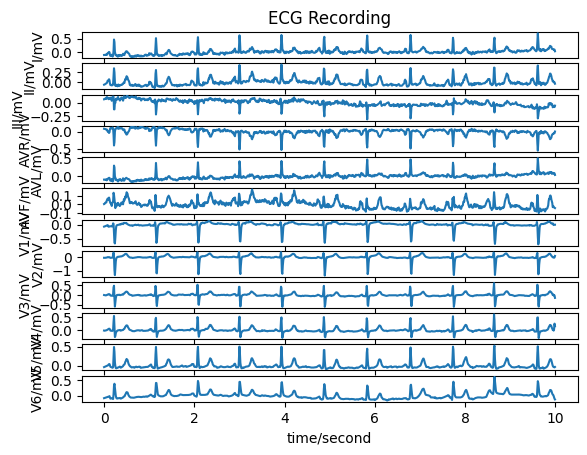

In [17]:
wfdb.plot_wfdb(record=record, title='ECG Recording')
plt.show()

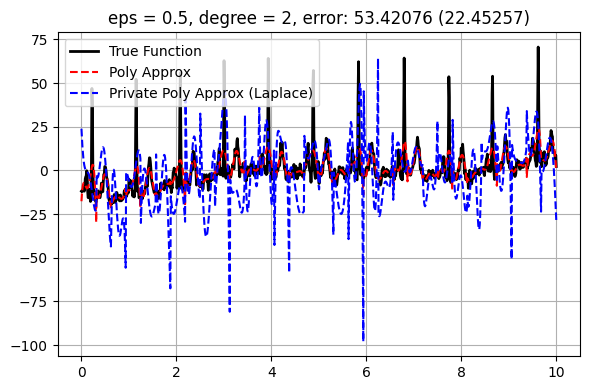

CPU times: user 2min 10s, sys: 220 ms, total: 2min 10s
Wall time: 1min 50s


In [18]:
%%time
t = np.linspace(0, record.p_signal.shape[0]/record.fs, record.p_signal.shape[0])
func = time_series_func(t, record.p_signal[:, 0]*100)
approx, priv, err_ls, err_priv = adaptive_poly_approx(func = func, interval = (0, t[-1]), basis = 'Fourier', degree = 2)
plot_1D_1D(func, (0, t[-1]), approx, priv, err_ls, err_priv, 0.5, 2, 'Laplace')

24.2064422463079 29.292129685644817
CPU times: user 39.4 s, sys: 63.9 ms, total: 39.5 s
Wall time: 32.7 s


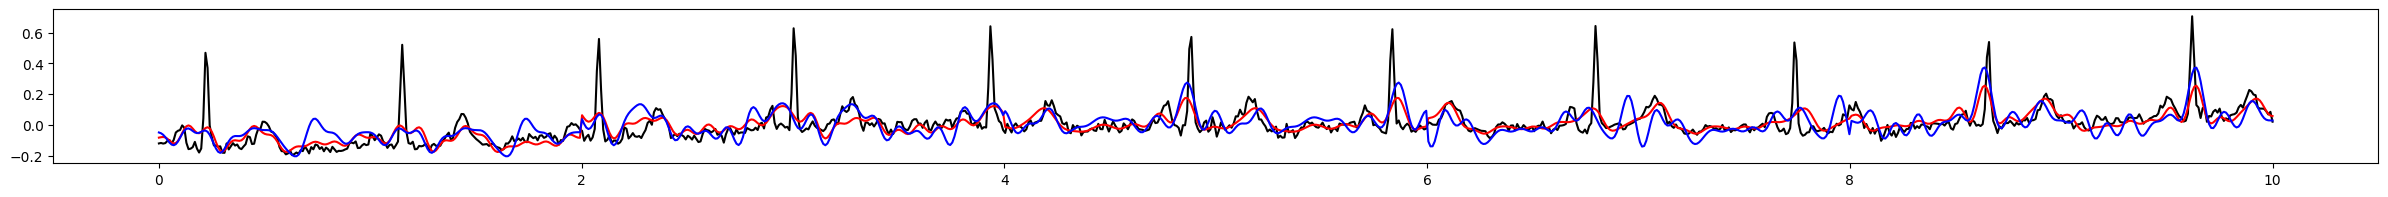

In [19]:
%%time
t = np.linspace(0, record.p_signal.shape[0]/record.fs, record.p_signal.shape[0])
func = time_series_func(t, record.p_signal[:, 0]*100)
solver = PrivateLeastSquaresApprox((0, 10), [0, 2, 4, 6, 8, 10], 'Fourier', 10)
_, _, approx, priv = solver.solve(func)
print(l2_dist(func, approx, 0, 10), l2_dist(func, priv, 0, 10))
plt.figure(figsize = (30, 2))
plt.plot(t, func(t)/100, color = 'black')
plt.plot(t, approx(t)/100, color = 'red')
plt.plot(t, priv(t)/100, color = 'blue')

71.21051122110718 73.82464024526011
CPU times: user 47.7 s, sys: 50.1 ms, total: 47.8 s
Wall time: 43.9 s


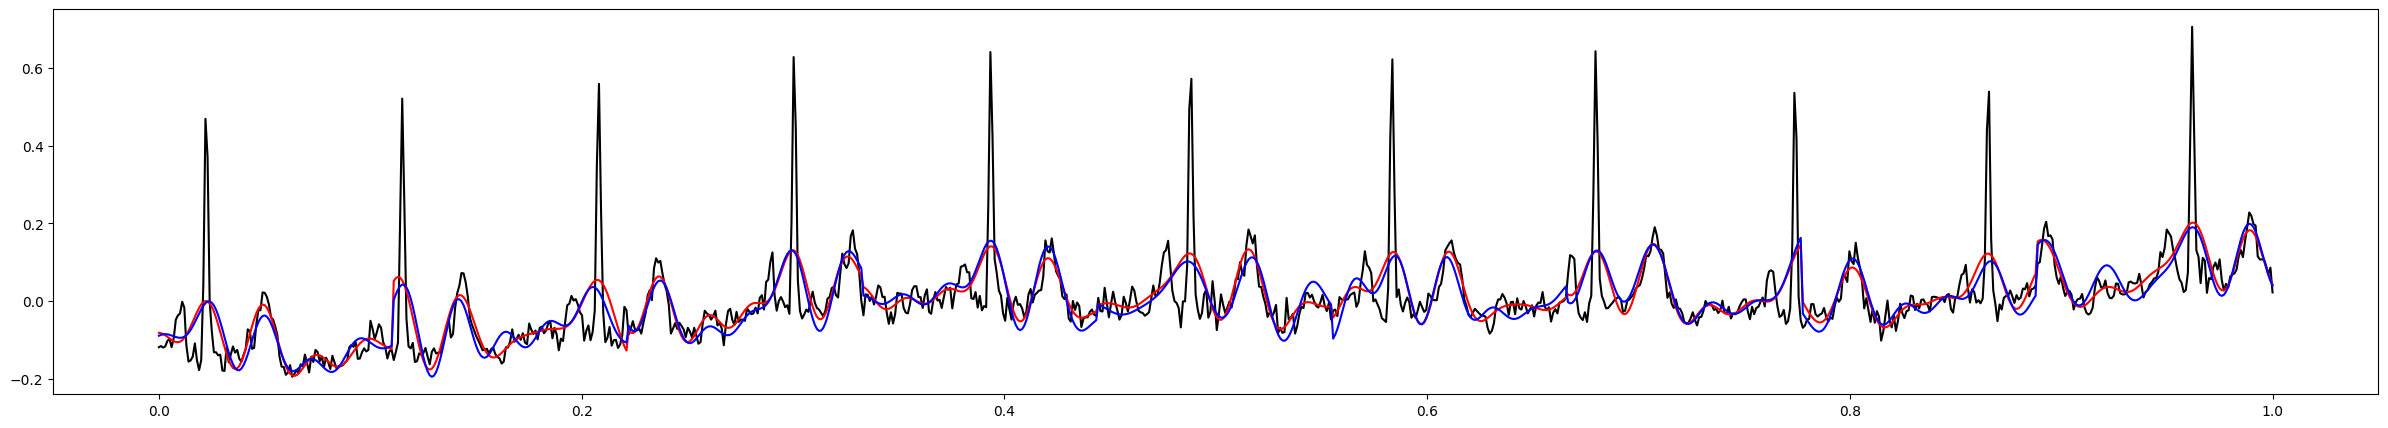

In [20]:
%%time
T = record.p_signal.shape[0]/record.fs*10
t = np.linspace(0, T, record.p_signal.shape[0])
func = time_series_func(t, record.p_signal[:, 0]*100)
solver = PrivateLeastSquaresApprox((0, T), np.linspace(0, T, 10), 'Sinc', 10)
_, _, approx, priv = solver.solve(func)
print(l2_dist(func, approx, 0, T), l2_dist(func, priv, 0, T))
plt.figure(figsize = (30, 5))
plt.plot(t/100, func(t)/100, color = 'black')
plt.plot(t/100, approx(t)/100, color = 'red')
plt.plot(t/100, priv(t)/100, color = 'blue')

### Respiration Signals Approximations

In [21]:
dir_list = []; t_list = []; val_list = []
for subdir in sorted(os.listdir("ecg-spider-clip")):
    if os.path.isdir("ecg-spider-clip/"+subdir):
        record = pd.read_csv("ecg-spider-clip/"+subdir+"/BitalinoBR.txt", header = None, sep = '\s+', dtype = str)
        dir_list.append(subdir)
        val_list.append(record[0].to_numpy(dtype = np.float64))
        record[2] = record[1].apply(lambda t: int(t[:2])*60*60+int(t[2:4])*60+int(t[4:6])%100+int(t.split(".")[1])/1000)
        t_list.append(record[2].to_numpy()-record[2].to_numpy()[0])
df = pd.DataFrame({'dir': dir_list, 't': t_list, 'val': val_list})
df.head()

,dir,t,val
0,VP02,"[0.0, 0.01599999999598367, 0.02100000000064028...","[-3.3203125, -3.7109375, -4.00390625, -4.29687..."
1,VP03,"[0.0, 0.0070000000050640665, 0.014000000002852...","[6.0546875, 7.421875, 8.69140625, 9.9609375, 1..."
2,VP05,"[0.0, 0.010999999998603016, 0.0169999999998253...","[2.24609375, 2.24609375, 2.1484375, 1.953125, ..."
3,VP06,"[0.0, 0.010000000002037268, 0.0159999999959836...","[-5.46875, -5.37109375, -5.37109375, -5.273437..."
4,VP08,"[0.0, 0.05099999999947613, 0.05600000000413274...","[0.9765625, 0.87890625, 0.68359375, 0.68359375..."


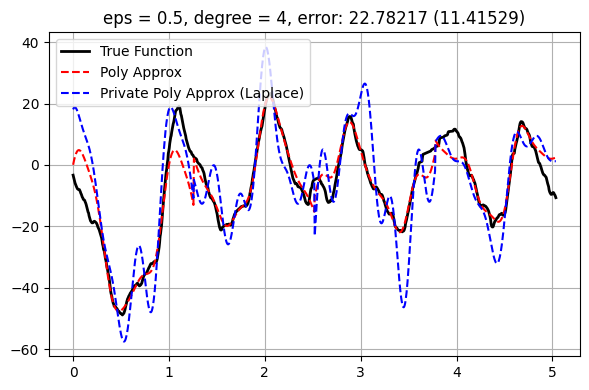

CPU times: user 16 s, sys: 12 ms, total: 16 s
Wall time: 16 s


In [22]:
%%time
t = df['t'][0][:2000]/4
val = df['val'][0][:2000]
func = time_series_func(t, val)
approx, priv, err_ls, err_priv = adaptive_poly_approx(func = func, interval = (t[0], t[-1]), basis = 'Fourier', degree = 4)
plot_1D_1D(func, (t[0], t[-1]), approx, priv, err_ls, err_priv, 0.5, 4, 'Laplace')

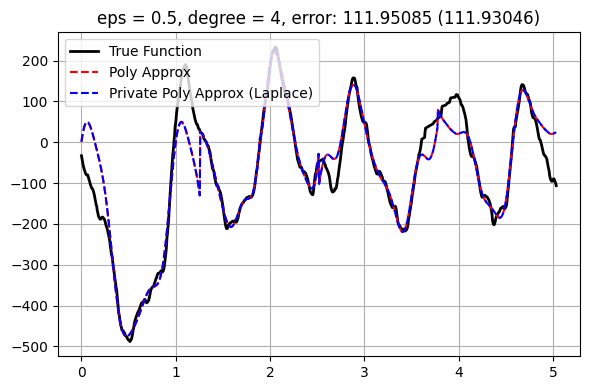

In [ ]:
%%time
t = df['t'][0][:2000]/4
val = df['val'][0][:2000]*10
func = time_series_func(t, val)
approx, priv, err_ls, err_priv = adaptive_poly_approx(func = func, interval = (t[0], t[-1]), basis = 'Fourier', degree = 4)
plot_1D_1D(func, (t[0], t[-1]), approx, priv, err_ls, err_priv, 0.5, 4, 'Laplace')

## Archived

### Taxi Trajectory

In [15]:
df = pd.read_csv('taxi.csv')[:1000]
df['pts'] = df['POLYLINE'].apply(loads)
df = df[df['pts'].apply(len) > 0].reset_index(drop = True)
df['x'] = df['pts'].apply(lambda arr: [row[0] for row in arr])
df['y'] = df['pts'].apply(lambda arr: [row[1] for row in arr])
df['min_x'] = df['x'].apply(np.min)
df['max_x'] = df['x'].apply(np.max)
df['min_y'] = df['y'].apply(np.min)
df['max_y'] = df['y'].apply(np.max)
df[['x', 'y', 'min_x', 'max_x', 'min_y', 'max_y']]

,x,y,min_x,max_x,min_y,max_y
0,"[-8.618643, -8.618499, -8.620326, -8.622153, -...","[41.141412, 41.141376, 41.14251, 41.143815, 41...",-8.632746,-8.618499,41.141376,41.154516
1,"[-8.639847, -8.640351, -8.642196, -8.644455, -...","[41.159826, 41.159871, 41.160114, 41.160492, 4...",-8.670942,-8.639847,41.159826,41.170671
2,"[-8.612964, -8.613378, -8.614215, -8.614773, -...","[41.140359, 41.14035, 41.140278, 41.140368, 41...",-8.650395,-8.596530,41.140278,41.154507
3,"[-8.574678, -8.574705, -8.574696, -8.57466, -8...","[41.151951, 41.151942, 41.151933, 41.15196, 41...",-8.610849,-8.574660,41.142555,41.151960
4,"[-8.645994, -8.645949, -8.646048, -8.646804, -...","[41.18049, 41.180517, 41.180049, 41.178888, 41...",-8.689086,-8.645949,41.171841,41.180517
...,...,...,...,...,...,...
994,"[-8.611398, -8.610714, -8.609364, -8.607852, -...","[41.143113, 41.143167, 41.143275, 41.142798, 4...",-8.617221,-8.605053,41.137344,41.147910
995,"[-8.628984, -8.628894, -8.628912, -8.628543, -...","[41.161023, 41.160996, 41.160987, 41.160798, 4...",-8.630307,-8.605161,41.142807,41.219640
996,"[-8.585775, -8.58582, -8.58573, -8.586036, -8....","[41.148531, 41.14863, 41.148891, 41.148963, 41...",-8.609472,-8.578791,41.145030,41.184639
997,"[-8.606601, -8.606457, -8.606349, -8.606322, -...","[41.147955, 41.14791, 41.148099, 41.148189, 41...",-8.670510,-8.581149,41.147190,41.238828


In [16]:
min_x = df['min_x'].min(); max_x = df['max_x'].max()
min_y = df['min_y'].min(); max_y = df['max_y'].max()
print(min_x, max_x, max_x-min_x, '\n', min_y, max_y, max_y-min_y)

-8.709399 -8.486757 0.22264199999999867 
 41.008275 41.260086 0.25181100000000356


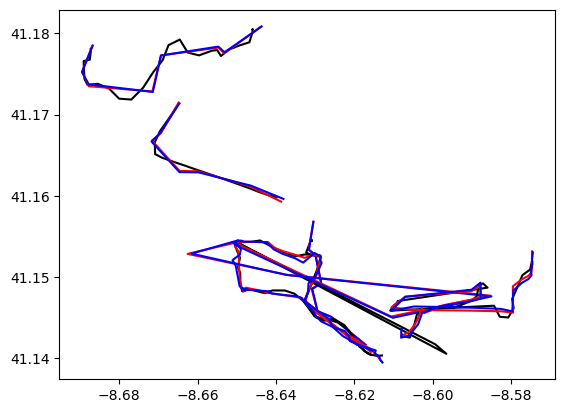

In [17]:
# for i in range(df.shape[0]):
for i in range(5):
    x = (df['x'][i]-min_x)*10000
    y = (df['y'][i]-min_y)*10000
    t = np.arange(len(x))
    if len(t) <= 1:
        continue
    func_x = time_series_func(t, x)
    func_y = time_series_func(t, y)
    approx_x, priv_x, err_ls_x, err_priv_x = adaptive_poly_approx(func = func_x, interval = (0, len(t)-1), degree = 1)
    approx_y, priv_y, err_ls_y, err_priv_y = adaptive_poly_approx(func = func_y, interval = (0, len(t)-1), degree = 1)
    logging.info(f"Approx x: {approx_x(t)}\nApprox y: {approx_y(t)}\n\n")
    plt.plot(x/10000+min_x, y/10000+min_y, color = 'black')
    plt.plot(approx_x(t)/10000+min_x, approx_y(t)/10000+min_y, color = 'red')
    plt.plot(priv_x(t)/10000+min_x, priv_y(t)/10000+min_y, color = 'blue')
plt.show()

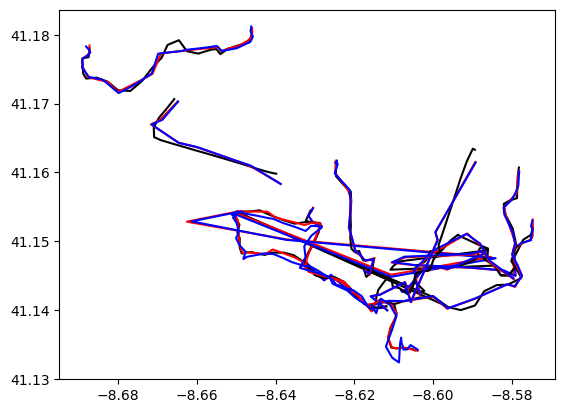

In [18]:
# for i in range(df.shape[0]):
for i in range(10):
    x = (df['x'][i]-min_x)*10000
    y = (df['y'][i]-min_y)*10000
    t = np.arange(len(x))
    if len(t) <= 1:
        continue
    func_x = time_series_func(t, x)
    func_y = time_series_func(t, y)
    approx_x, priv_x, err_ls_x, err_priv_x = adaptive_poly_approx(func = func_x, interval = (0, len(t)-1), degree = 1)
    approx_y, priv_y, err_ls_y, err_priv_y = adaptive_poly_approx(func = func_y, interval = (0, len(t)-1), degree = 1)
    # plot_1D_1D(func_x, (0, len(t)-1), approx_x, priv_x, err_ls_x, err_priv_x, 0.5, 1, 'Laplace')
    # plot_1D_1D(func_y, (0, len(t)-1), approx_y, priv_y, err_ls_y, err_priv_y, 0.5, 1, 'Laplace')
    logging.info(f"Approx x: {approx_x(t)}\nApprox y: {approx_y(t)}\n\n")
    plt.plot(x/10000+min_x, y/10000+min_y, color = 'black')
    plt.plot(approx_x(t)/10000+min_x, approx_y(t)/10000+min_y, color = 'red')
    plt.plot(priv_x(t)/10000+min_x, priv_y(t)/10000+min_y, color = 'blue')
plt.show()

In [ ]:
heatmap, xedges, yedges = np.histogram2d(np.concat(df['x']), np.concat(df['y']), bins = 100)
plt.imshow(heatmap.T, extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]], origin = 'lower', cmap = 'hot', aspect = 'auto')

### COVID Cases

In [10]:
df = pd.read_csv('covid-19-data/public/data/cases_deaths/weekly_cases.csv').dropna()
y = df['World']
y = np.array(y.loc[y.shift(-1) != y])

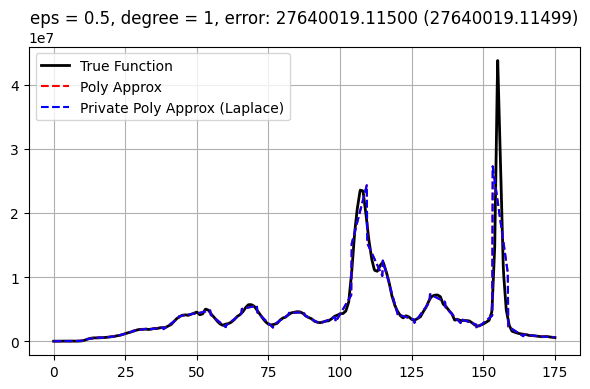

In [11]:
func = time_series_func(np.arange(len(y)), y)
solver = PrivateLeastSquaresApprox((0, len(y)-1), np.linspace(0, len(y)-1, 33), 1)
_, _, approx, priv = solver.solve(func, method = 'Laplace')
err_ls = l2_dist(func, approx, 0, len(y)-1)
err_priv = l2_dist(func, priv, 0, len(y)-1)
plot_1D_1D(func, (0, len(y)-1), approx, priv, err_ls, err_priv, 0.5, 1, 'Laplace')

/tmp/ipykernel_11420/3794273414.py:3: RuntimeWarning: invalid value encountered in log2
  y_approx = np.log2(approx(x_plot))
/tmp/ipykernel_11420/3794273414.py:4: RuntimeWarning: invalid value encountered in log2
  y_priv = np.log2(priv(x_plot))


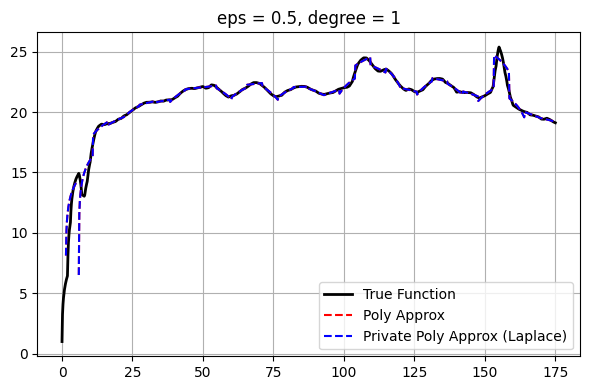

In [12]:
x_plot = np.linspace(0, len(y)-1, INTLIM)
y_true = np.log2(func(x_plot))
y_approx = np.log2(approx(x_plot))
y_priv = np.log2(priv(x_plot))

plt.figure(figsize = (6, 4))
plt.plot(x_plot, y_true, 'k-', linewidth = 2, label = 'True Function')
plt.plot(x_plot, y_approx, 'r--', linewidth = 1.5, label = 'Poly Approx')
plt.plot(x_plot, y_priv, 'b--', linewidth = 1.5, label = f'Private Poly Approx (Laplace)')
plt.title(f"eps = 0.5, degree = 1")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

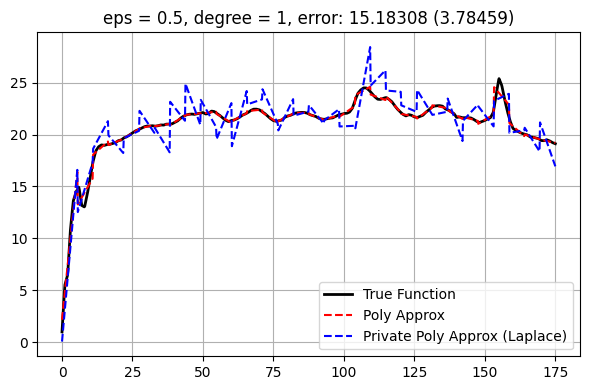

In [13]:
y_log = np.log2(y)
func = time_series_func(np.arange(len(y)), y_log)
solver = PrivateLeastSquaresApprox((0, len(y)-1), np.linspace(0, len(y)-1, 33), 1)
_, _, approx, priv = solver.solve(func, method = 'Laplace')
err_ls = l2_dist(func, approx, 0, len(y)-1)
err_priv = l2_dist(func, priv, 0, len(y)-1)
plot_1D_1D(func, (0, len(y)-1), approx, priv, err_ls, err_priv, 0.5, 1, 'Laplace')

In [14]:
"""
func = time_series_func(np.arange(len(y)), y)
approx, priv, err_ls, err_priv = adaptive_poly_approx(func = func, interval = (0, len(y)-1), degree = 1)
plot_1D_1D(func, (0, len(y)-1), approx, priv, err_ls, err_priv, 0.5, 3, 'Laplace')
"""

"\nfunc = time_series_func(np.arange(len(y)), y)\napprox, priv, err_ls, err_priv = adaptive_poly_approx(func = func, interval = (0, len(y)-1), degree = 1)\nplot_1D_1D(func, (0, len(y)-1), approx, priv, err_ls, err_priv, 0.5, 3, 'Laplace')\n"

### Trip Record

In [20]:
"""
df = pd.read_parquet('trip-records/yellow_tripdata_2025-01.parquet', engine = 'fastparquet')
df
"""

"\ndf = pd.read_parquet('trip-records/yellow_tripdata_2025-01.parquet', engine = 'fastparquet')\ndf\n"